# Descriptive of all delays flights

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


PROJECT_ID = "airplanes-501619"
client = bigquery.Client(project=PROJECT_ID)

In this example, we use bigquery-samples.airline_ontime_data.flights.

In [3]:
# --- Query 1: summary stats ---
summary_query_1 = """
SELECT
  AVG(departure_delay) AS mean,
  APPROX_QUANTILES(departure_delay, 4)[OFFSET(1)] AS q1,
  APPROX_QUANTILES(departure_delay, 4)[OFFSET(2)] AS median,
  APPROX_QUANTILES(departure_delay, 4)[OFFSET(3)] AS q3,
  STDDEV_SAMP(departure_delay) AS sd,
  MIN(departure_delay) AS min_delay,
  MAX(departure_delay) AS max_delay
FROM `bigquery-samples.airline_ontime_data.flights`
"""
summary_df_1 = client.query(summary_query_1).to_dataframe()

# --- Query 2: histogram bins, full range ---
histogram_query_1 = """
SELECT
  CAST(FLOOR(departure_delay/10)*10 AS INT64) AS bin,
  COUNT(*) AS frequency
FROM `bigquery-samples.airline_ontime_data.flights`
GROUP BY bin
ORDER BY bin
"""
hist_df_1 = client.query(histogram_query_1).to_dataframe()

mean = summary_df_1['mean'][0]
median = summary_df_1['median'][0]
q1 = summary_df_1['q1'][0]
q3 = summary_df_1['q3'][0]
sd = summary_df_1['sd'][0]

# Mean, median, Q1, Q3

We want to explore departure_delay. We query it to get summary statistics and to plot an histogram with 10min bins. There is a huge concentration of data in bins near zero, so we switch to a log scale to make the rest of the distribution visible. 

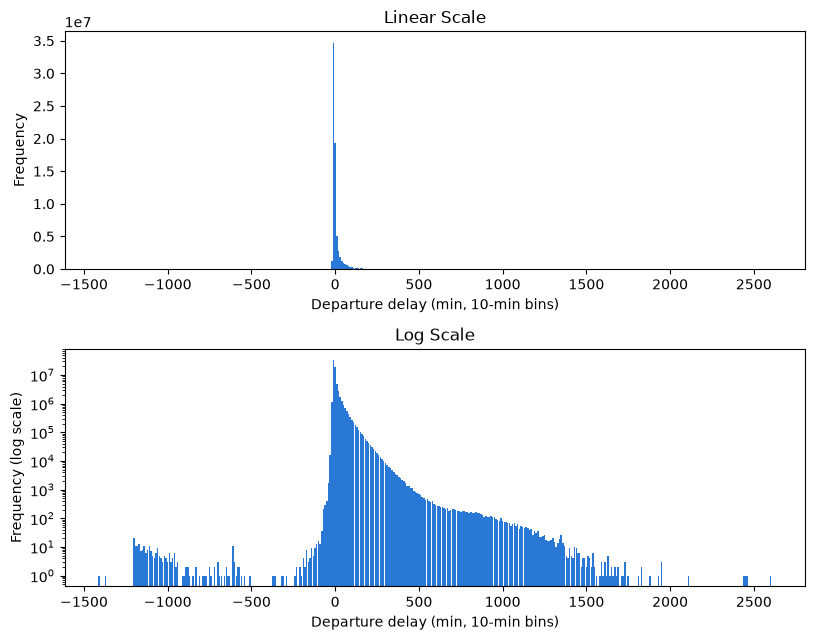

Mean:   8.39 min
Median: -1.0 min
Q1:     -4.0 min
Q3:     7.0 min
SD:     31.94 min


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.25, 6.5))

ax1.bar(hist_df_1['bin'], hist_df_1['frequency'], width=9, color='#2a78d6')
ax1.set_xlabel('Departure delay (min, 10-min bins)')
ax1.set_ylabel('Frequency')
ax1.set_title('Linear Scale')

ax2.bar(hist_df_1['bin'], hist_df_1['frequency'], width=9, color='#2a78d6')
ax2.set_yscale('log')
ax2.set_xlabel('Departure delay (min, 10-min bins)')
ax2.set_ylabel('Frequency (log scale)')
ax2.set_title('Log Scale')

plt.tight_layout()
plt.show()

print(f"Mean:   {mean:.2f} min")
print(f"Median: {median:.1f} min")
print(f"Q1:     {q1:.1f} min")
print(f"Q3:     {q3:.1f} min")
print(f"SD:     {sd:.2f} min")

At first look, taking into account the shape mean, median, Q1 and Q3 it looks right-skewed. But our attention is first drawn to some extreme negative values clustered around -1000. Knowing this is a delay data, we want to make sense of those values. 
Most of the extreme negative values clustered near -1000 are explained by overnight flights, where the delay calculation doesn't account for the departure crossing into the next day — producing a falsely extreme "early" value instead of the true (often small or positive) delay. 


In [5]:
outlier_raw_query = """
SELECT date, departure_schedule, departure_actual, departure_delay
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_delay < -500
ORDER BY departure_delay
LIMIT 10
"""
outlier_raw_df = client.query(outlier_raw_query).to_dataframe()
outlier_raw_df

,date,departure_schedule,departure_actual,departure_delay
0,2003-01-07,530,600,-1410.0
1,2002-12-06,530,640,-1370.0
2,2006-07-21,2130,130,-1200.0
3,2005-01-24,2005,6,-1199.0
4,2005-08-14,2110,111,-1199.0
5,2006-06-01,2355,356,-1199.0
6,2005-01-23,2235,236,-1199.0
7,2005-03-25,2010,12,-1198.0
8,2006-02-12,2245,248,-1197.0
9,2004-05-02,2020,23,-1197.0


We excluded extreme negative values by filtering departure_delay > -500 (these were confirmed to be a midnight-rollover data artifact, not real delays). The extreme positive values near 2500 min are likely genuine severe disruptions, but given how few flights they represent, we didn't investigate them further. After filtering, mean, median, etc. barely moved — because 50% of all data (Q1 to Q3) is already tightly clustered between -4 and 7 minutes, so a handful of removed extreme rows has almost no leverage on the aggregate stats.

In [19]:
# --- Query 1: summary stats, excluding known rollover-bug extreme negatives ---
summary_query_2 = """
SELECT
  AVG(departure_delay) AS mean,
  APPROX_QUANTILES(departure_delay, 4)[OFFSET(1)] AS q1,
  APPROX_QUANTILES(departure_delay, 4)[OFFSET(2)] AS median,
  APPROX_QUANTILES(departure_delay, 4)[OFFSET(3)] AS q3,
  STDDEV_SAMP(departure_delay) AS sd,
  MIN(departure_delay) AS min_delay,
  MAX(departure_delay) AS max_delay
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_delay > -500
"""
summary_df_2 = client.query(summary_query_2).to_dataframe()

# --- Query 2: histogram bins, excluding the same extreme negatives ---
histogram_query_2 = """
SELECT
  CAST(FLOOR(departure_delay/10)*10 AS INT64) AS bin,
  COUNT(*) AS frequency
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_delay > -500
GROUP BY bin
ORDER BY bin
"""
hist_df_2 = client.query(histogram_query_2).to_dataframe()

mean_2 = summary_df_2['mean'][0]
median_2 = summary_df_2['median'][0]
q1_2 = summary_df_2['q1'][0]
q3_2 = summary_df_2['q3'][0]
sd_2 = summary_df_2['sd'][0]

print(f"Mean:   {mean_2:.2f} min")
print(f"Median: {median_2:.1f} min")
print(f"Q1:     {q1_2:.1f} min")
print(f"Q3:     {q3_2:.1f} min")
print(f"SD:     {sd_2:.2f} min")


Mean:   8.40 min
Median: -1.0 min
Q1:     -4.0 min
Q3:     7.0 min
SD:     31.88 min


Observing the shape of the distribution, the mean vs median gap (8.4 vs -1), the median sitting a lot closer to Q1 than to Q3 and a Pearson's skewness coefficient of 0.884 we can confidently conclude this is a moderate right-skewed distribution.

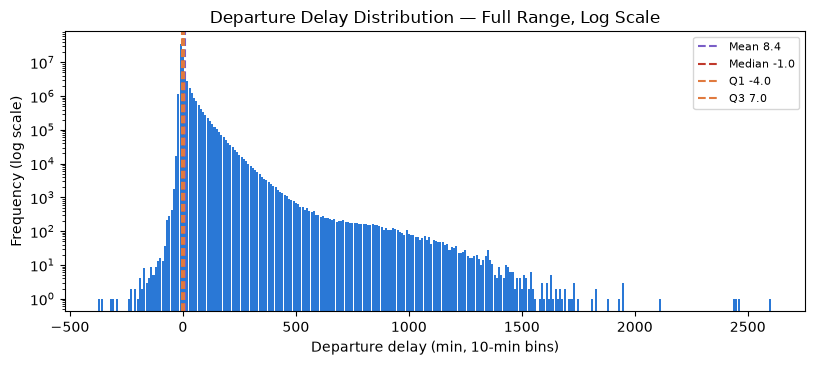

Mean:   8.40 min
Median: -1.0 min
Q1:     -4.0 min
Q3:     7.0 min
SD:     31.88 min
Pearson's skewness coefficient: 0.884


In [18]:
fig, ax = plt.subplots(figsize=(8.25, 3.75))
ax.bar(hist_df_2['bin'], hist_df_2['frequency'], width=9, color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('Departure delay (min, 10-min bins)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title('Departure Delay Distribution — Full Range, Log Scale')

markers = [(mean_2, f'Mean {mean_2:.1f}', '#7a5ec7'),
           (median_2, f'Median {median_2:.1f}', '#c0392b'),
           (q1_2, f'Q1 {q1_2:.1f}', '#e07a3f'),
           (q3_2, f'Q3 {q3_2:.1f}', '#e07a3f')]
for val, label, color in markers:
    ax.axvline(val, color=color, linestyle='--', linewidth=1.5, label=label)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Mean:   {mean_2:.2f} min")
print(f"Median: {median_2:.1f} min")
print(f"Q1:     {q1_2:.1f} min")
print(f"Q3:     {q3_2:.1f} min")
print(f"SD:     {sd_2:.2f} min")

pearson_skew = 3 * (mean_2 - median_2) / sd_2
print(f"Pearson's skewness coefficient: {pearson_skew:.3f}")

# Outliers

Being the distribution right-skewed, mean and standard deviation aren't reliable for defining "normal" — so we use IQR to set outlier boundaries instead. Using the 1.5×IQR rule, values outside roughly -20.5 to 23.5 minutes are flagged as statistical outliers. As the chart shows, this boundary sits well inside the bulk of on-time/near-on-time flights, meaning even a fairly large share of "everyday" delays technically fall outside the fence — a reminder that IQR outlier detection flags statistical rarity, not necessarily operational abnormality.

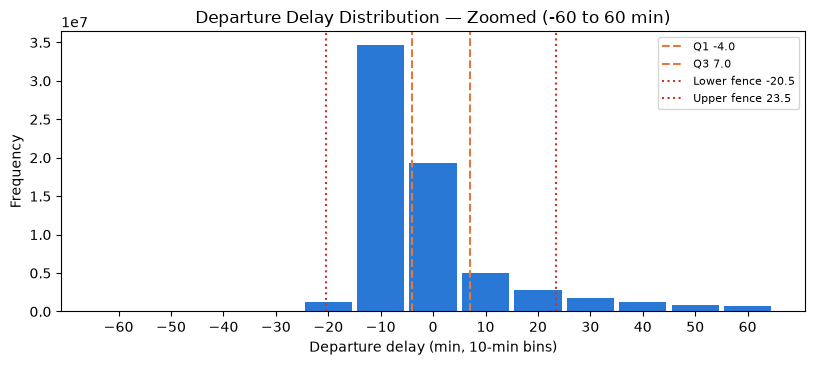

IQR: 11.0 | Outlier fences: [-20.5, 23.5]


In [15]:
iqr = q3_2 - q1_2
lower_fence = q1_2 - 1.5 * iqr
upper_fence = q3_2 + 1.5 * iqr

plot_range = hist_df_2[(hist_df_2['bin'] >= -60) & (hist_df_2['bin'] <= 60)]

fig, ax = plt.subplots(figsize=(8.25, 3.75))
ax.bar(plot_range['bin'], plot_range['frequency'], width=9, color='#2a78d6')
ax.set_xlabel('Departure delay (min, 10-min bins)')
ax.set_ylabel('Frequency')
ax.set_title('Departure Delay Distribution — Zoomed (-60 to 60 min)')

ax.axvline(q1_2, color='#e07a3f', linestyle='--', linewidth=1.5, label=f'Q1 {q1_2:.1f}')
ax.axvline(q3_2, color='#e07a3f', linestyle='--', linewidth=1.5, label=f'Q3 {q3_2:.1f}')
ax.axvline(lower_fence, color='#c0392b', linestyle=':', linewidth=1.5, label=f'Lower fence {lower_fence:.1f}')
ax.axvline(upper_fence, color='#c0392b', linestyle=':', linewidth=1.5, label=f'Upper fence {upper_fence:.1f}')

ax.set_xticks(range(-60, 61, 10))

plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"IQR: {iqr:.1f} | Outlier fences: [{lower_fence:.1f}, {upper_fence:.1f}]")

# Confidence interval (CI) 

If there's one main question we want to answer with this data, it's "What is the average departure delay?" We'll focus on the route ORD–MIA and its two main airlines, AA and UA, and calculate the confidence interval for their average delay across all years. 

In [12]:
route_query = """
SELECT
  airline,
  COUNT(*) AS n,
  AVG(departure_delay) AS mean_delay,
  STDDEV_SAMP(departure_delay) AS sd
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_airport = 'ORD'
  AND arrival_airport = 'MIA'
  AND airline IN ('AA', 'UA')
GROUP BY airline
"""
route_df = client.query(route_query).to_dataframe()# route_df

AA has an average departure delay of 15.7 minutes (95% CI : 15.3  -  16.1).
Compared with the UA average departure delay of 13.0 minutes (95% CI : 12.1  -  13.9).


In [13]:
route_df['se'] = route_df['sd'] / np.sqrt(route_df['n'])
route_df['ci_lower'] = route_df['mean_delay'] - 1.96 * route_df['se']
route_df['ci_upper'] = route_df['mean_delay'] + 1.96 * route_df['se']

route_df[['airline', 'n', 'mean_delay', 'sd', 'ci_lower', 'ci_upper']]

,airline,n,mean_delay,sd,ci_lower,ci_upper
0,AA,33219,15.732864,39.932188,15.30344,16.162287
1,UA,6018,13.041044,36.751294,12.112499,13.969588


# P-value

Does the departure delay difference between AA and UA make one a meaningfully better choice — or could this gap just be random noise? We'll use a p-value to test whether the difference is statistically significant. With a p-value of 0.00000026 (< 0.05), we can state this is a result unlikely to occur by chance, giving strong statistical evidence to reject H0 — meaning there is a real difference in average delay between the two airlines on this route.

In [14]:
aa = route_df[route_df['airline'] == 'AA'].iloc[0]
ua = route_df[route_df['airline'] == 'UA'].iloc[0]

t_stat, p_value = stats.ttest_ind_from_stats(
    mean1=aa['mean_delay'], std1=aa['sd'], nobs1=aa['n'],
    mean2=ua['mean_delay'], std2=ua['sd'], nobs2=ua['n'],
    equal_var=False  
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.8f}")

t-statistic: 5.157
p-value: 0.00000026


In this example, let's focus on the year 2003. Here, with a p-value of 0.97227044 (> 0.05), we can state this result could very plausibly occur by chance — there isn't enough evidence to reject H0, meaning we can't conclude a real difference in average delay between AA and UA on this route that year.

In [15]:
route_query = """
SELECT
  airline,
  COUNT(*) AS n,
  AVG(departure_delay) AS mean_delay,
  STDDEV_SAMP(departure_delay) AS sd
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_airport = 'ORD'
  AND arrival_airport = 'MIA'
  AND airline IN ('AA', 'UA')
  AND EXTRACT(YEAR FROM PARSE_DATE('%Y-%m-%d', date)) = 2003
GROUP BY airline
"""
route_df = client.query(route_query).to_dataframe()

aa = route_df[route_df['airline'] == 'AA'].iloc[0]
ua = route_df[route_df['airline'] == 'UA'].iloc[0]

t_stat, p_value = stats.ttest_ind_from_stats(
    mean1=aa['mean_delay'], std1=aa['sd'], nobs1=aa['n'],
    mean2=ua['mean_delay'], std2=ua['sd'], nobs2=ua['n'],
    equal_var=False  # Welch's t-test, safer when variances may differ
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.8f}")

t-statistic: -0.035
p-value: 0.97227044


# CV comparison

We compare mean departure delays from ORD flights in AA airline across all months. December and January have the highest means, but their CV is comparatively low. September and October, in contrast, have close to half the mean delay of those months, yet a much higher CV.
From this we can say December–January is consistently high-delay, while September–October is more unpredictable — some days close to on-time, others unexpectedly bad — despite a lower average delay.

In [7]:
seasonal_query = """
SELECT
  EXTRACT(MONTH FROM PARSE_DATE('%Y-%m-%d', date)) AS month,
  COUNT(*) AS n,
  AVG(departure_delay) AS mean_delay,
  STDDEV_SAMP(departure_delay) AS sd
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_airport = 'ORD'
  AND airline = 'AA'
  AND EXTRACT(MONTH FROM PARSE_DATE('%Y-%m-%d', date)) IN (1,2,3,4,5,6,7,8,9,10,11,12)
GROUP BY month
ORDER BY month
"""
seasonal_df = client.query(seasonal_query).to_dataframe()
seasonal_df['cv'] = seasonal_df['sd'] / seasonal_df['mean_delay']

seasonal_df

,month,n,mean_delay,sd,cv
0,1,67487,15.265192,38.487756,2.521276
1,2,61617,13.451077,35.082360,2.608145
2,3,69957,14.192590,37.380482,2.633803
3,4,67793,9.753087,30.804860,3.158473
4,5,69422,11.173749,34.063759,3.048552
5,6,67387,14.818422,37.993180,2.563915
6,7,69600,14.320230,38.546979,2.691785
7,8,69534,12.118676,35.694570,2.945418
8,9,65530,7.609293,28.824207,3.788027
9,10,63834,7.230520,26.962266,3.728953


# Correlation vs causation

Do airlines compensate for lost time if they depart with a small delay? To test this, we compare route SEA–MIA flights with departure delays under 20 min vs those over 60 min.

The data shows both groups recover some time while flying — but the difference between their average recovery (0,85 min) is small relative to the much larger gap in delay they each had to make up (20 min vs 60+ min).

To check if this difference is meaningful, we run a t-test. It returns a p-value of 0.64129 — well above 0.05, so there isn't enough evidence to reject H0. The difference in recovery between the two groups is consistent with random noise, not a real effect.

In [8]:
recovery_query = """
SELECT
  CASE
    WHEN departure_delay BETWEEN 0 AND 20 THEN 'Small delay (0-20min)'
    WHEN departure_delay > 60 THEN 'Large delay (60min+)'
  END AS delay_group,
  COUNT(*) AS n,
  AVG(departure_delay) AS avg_departure_delay,
  AVG(arrival_delay) AS avg_arrival_delay,
  AVG(arrival_delay - departure_delay) AS avg_recovery,
  STDDEV_SAMP(arrival_delay - departure_delay) AS sd_recovery
FROM `bigquery-samples.airline_ontime_data.flights`
WHERE departure_airport = 'SEA'
  AND arrival_airport = 'MIA'
  AND (departure_delay BETWEEN 0 AND 20 OR departure_delay > 60)
GROUP BY delay_group
"""
recovery_df = client.query(recovery_query).to_dataframe()
recovery_df

,delay_group,n,avg_departure_delay,avg_arrival_delay,avg_recovery,sd_recovery
0,Small delay (0-20min),1266,6.156398,4.189573,-1.966825,14.030532
1,Large delay (60min+),108,115.444444,112.629630,-2.814815,18.415834


In [9]:
small = recovery_df[recovery_df['delay_group'] == 'Small delay (0-20min)'].iloc[0]
large = recovery_df[recovery_df['delay_group'] == 'Large delay (60min+)'].iloc[0]

t_stat, p_value = stats.ttest_ind_from_stats(
    mean1=small['avg_recovery'], std1=small['sd_recovery'], nobs1=small['n'],
    mean2=large['avg_recovery'], std2=large['sd_recovery'], nobs2=large['n'],
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

t-statistic: 0.467
p-value: 0.64129


This ties back to correlation vs. causation: having a plausible mechanism (pilots speeding up to compensate for a short delay) isn't the same as evidence of that mechanism actually happening. Even though departure_delay and arrival_delay are strongly correlated overall, testing this specific causal hypothesis found no meaningful difference in recovery between small and large delays — a reminder that correlation between two variables doesn't validate every causal story you can construct around it.